<a href="https://colab.research.google.com/github/oy-hotwater/sneaker-similar-image-search/blob/main/sneaker_similar_image_search.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# セル1: 環境構築と認証、データダウンロード
# faiss-gpu はバージョン不整合が起きやすいため、安定した faiss-cpu を採用
!pip install -q faiss-cpu
!pip install -q kaggle

import os
from google.colab import userdata

# 1. Kaggle認証の設定 (Colabのシークレットから取得)
try:
    os.environ['KAGGLE_USERNAME'] = userdata.get('KAGGLE_USERNAME')
    os.environ['KAGGLE_KEY'] = userdata.get('KAGGLE_KEY')
    print("Kaggle認証情報の設定が完了しました。")
except Exception as e:
    print("エラー: シークレット 'KAGGLE_USERNAME' と 'KAGGLE_KEY' を設定してください。")
    raise e

import kaggle

# 2. データセットのダウンロード
# nikolasgegenava/sneakers-classification を指定
DATASET_PATH = "nikolasgegenava/sneakers-classification"
!kaggle datasets download -d $DATASET_PATH --unzip

# 3. ディレクトリ構造の確認とパスの設定
# このデータセットは通常 'train/', 'test/', 'validation/' フォルダに分かれています
IMAGE_DIR = "./"
print("データセットの解凍が完了しました。")

# フォルダ構造を表示して確認
!ls -F


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.8/23.8 MB 68.5 MB/s eta 0:00:00
Kaggle認証情報の設定が完了しました。
Dataset URL: https://www.kaggle.com/datasets/nikolasgegenava/sneakers-classification
License(s): MIT
  0% 0.00/17.1M [00:00<?, ?B/s]
100% 17.1M/17.1M [00:00<00:00, 1.18GB/s]
データセットの解凍が完了しました。
dataset_stats.csv  sample_data/  sneakers-dataset/


In [ ]:
# セル2: モジュールのインポートとパラメータ設定
import numpy as np
import tensorflow as tf
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input
from tensorflow.keras.preprocessing import image
import faiss
import matplotlib.pyplot as plt
from pathlib import Path
from tqdm import tqdm
import cv2

# 設定
BATCH_SIZE = 64
IMAGE_SIZE = (224, 224) # ResNet50の入力サイズ

In [ ]:
# --- Step 3: 画像パスの収集とモデル準備 ---
from pathlib import Path
import tensorflow as tf
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input
import numpy as np
import faiss
from tqdm import tqdm

# 画像パスの収集 (サブディレクトリをすべて再帰的に探索)
image_paths = []
for ext in ('*.jpg', '*.jpeg', '*.png'):
    image_paths.extend(Path(IMAGE_DIR).rglob(ext))
image_paths = [str(p) for p in image_paths if "checkpoint" not in str(p)] # .ipynb_checkpointsを除外

print(f"検出された画像数: {len(image_paths)}枚")
if len(image_paths) == 0:
    raise ValueError("画像が見つかりません。解凍されたフォルダ名を確認してください。")

# 特徴抽出モデル (ResNet50)
base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(224, 224, 3), pooling='avg')

検出された画像数: 5953枚
94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
# --- Step 4: 特徴抽出とFaiss(CPU)インデックス構築 ---
def load_and_preprocess(path):
    img = tf.io.read_file(path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, (224, 224))
    img = preprocess_input(img)
    return img

# tf.dataによる効率的なバッチ処理
dataset = tf.data.Dataset.from_tensor_slices(image_paths)
dataset = dataset.map(load_and_preprocess).batch(64).prefetch(tf.data.AUTOTUNE)

print("特徴抽出中...")
features = []
for batch in tqdm(dataset):
    f = base_model.predict(batch, verbose=0)
    features.append(f)

all_features = np.vstack(features)
faiss.normalize_L2(all_features) # L2正規化

# Faiss IndexFlatIP (CPU版) の作成
dimension = all_features.shape[1]
index = faiss.IndexFlatIP(dimension) # CPU上で動作
index.add(all_features)

print(f"Faissインデックス作成完了: {index.ntotal} 件")

特徴抽出中...


100%|██████████| 94/94 [26:22<00:00, 16.83s/it]

Faissインデックス作成完了: 5953 件


テスト検索実行: クエリ画像 = sneakers-dataset/sneakers-dataset/new_balance_574/0106.jpg


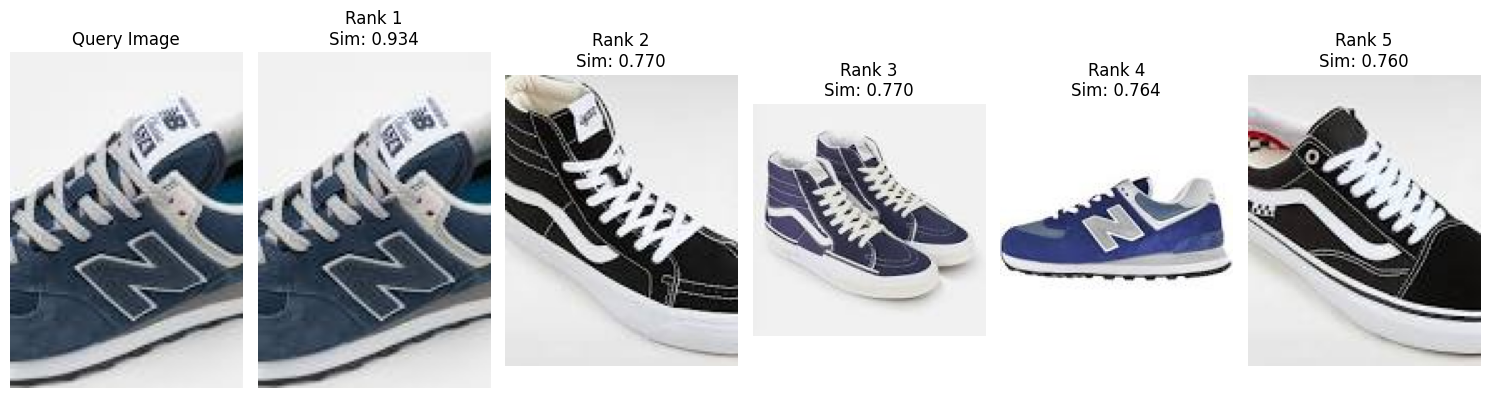

In [ ]:
# セル5: 検索機能の実装と可視化
def search_similar_sneakers(query_image_path, top_k=5):
    """
    クエリ画像に対して類似するスニーカーを検索し、可視化する関数
    """
    if not os.path.exists(query_image_path):
        print(f"エラー: クエリ画像が見つかりません: {query_image_path}")
        return

    # クエリ画像の前処理
    img = image.load_img(query_image_path, target_size=IMAGE_SIZE)
    img_array = image.img_to_array(img)
    img_array_expanded = np.expand_dims(img_array, axis=0)
    preprocessed_img = preprocess_input(img_array_expanded)

    # 特徴抽出
    query_feature = base_model.predict(preprocessed_img, verbose=0)

    # L2正規化
    faiss.normalize_L2(query_feature)

    # 検索実行
    # distances: 類似度スコア (1に近いほど似ている), indices: 画像のインデックス番号
    distances, indices = index.search(query_feature, top_k)

    # 結果の可視化
    plt.figure(figsize=(15, 5))

    # クエリ画像の表示
    plt.subplot(1, top_k + 1, 1)
    original_query = cv2.imread(query_image_path)
    original_query = cv2.cvtColor(original_query, cv2.COLOR_BGR2RGB)
    plt.imshow(original_query)
    plt.title("Query Image")
    plt.axis('off')

    # 検索結果の表示
    for i in range(top_k):
        idx = indices[0][i]
        score = distances[0][i]
        result_path = image_paths[idx]

        result_img = cv2.imread(result_path)
        result_img = cv2.cvtColor(result_img, cv2.COLOR_BGR2RGB)

        plt.subplot(1, top_k + 1, i + 2)
        plt.imshow(result_img)
        # スコアを小数点3桁で表示
        plt.title(f"Rank {i+1}\nSim: {score:.3f}")
        plt.axis('off')

    plt.tight_layout()
    plt.show()

# --- テスト実行 ---
# データセット内の適当な画像をクエリとしてテスト
if len(image_paths) > 0:
    test_query_path = image_paths[0] # 別の画像をアップロードしてそのパスを指定しても良いです
    print(f"テスト検索実行: クエリ画像 = {test_query_path}")
    search_similar_sneakers(test_query_path, top_k=5)